Saving Superstore.csv to Superstore (7).csv
File uploaded: Superstore (7).csv

Dataset loaded successfully!
Rows: 9994
Columns: 21

Columns:
['row_id', 'order_id', 'order_date', 'ship_date', 'ship_mode', 'customer_id', 'customer_name', 'segment', 'country', 'city', 'state', 'postal_code', 'region', 'product_id', 'category', 'sub-category', 'product_name', 'sales', 'quantity', 'discount', 'profit']

Cleaned Dataset:


,row_id,order_id,order_date,ship_date,ship_mode,customer_id,customer_name,segment,country,city,...,postal_code,region,product_id,category,sub-category,product_name,sales,quantity,discount,profit
0,1,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


KEY PERFORMANCE INDICATORS
Total Sales     : 2297200.86
Total Profit    : 286397.02
Total Quantity  : 37873
Profit Margin   : 12.47 %

CATEGORY PERFORMANCE


,sales,profit
category,,
Furniture,741999.7953,18451.2728
Office Supplies,719047.0320,122490.8008
Technology,836154.0330,145454.9481


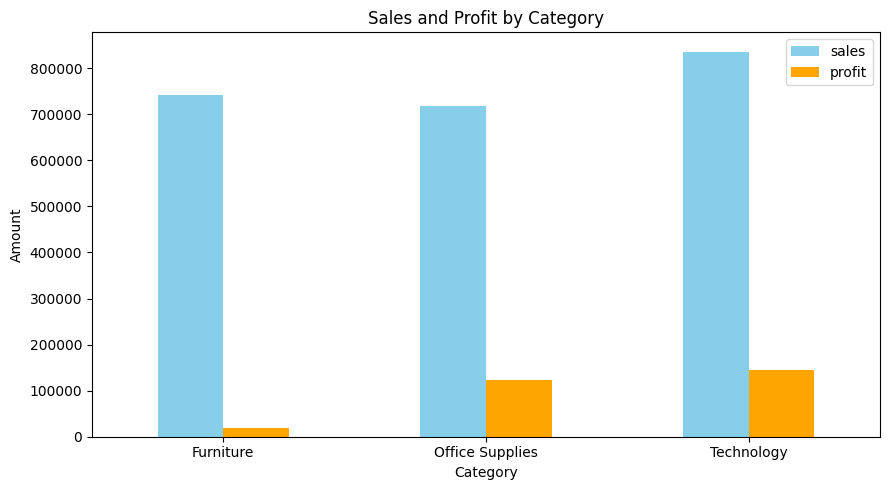


REGIONAL PERFORMANCE


,sales,profit
region,,
Central,501239.8908,39706.3625
East,678781.2400,91522.7800
South,391721.9050,46749.4303
West,725457.8245,108418.4489


/tmp/ipykernel_504/3326764370.py:108: FutureWarning:

'M' is deprecated and will be removed in a future version, please use 'ME' instead.



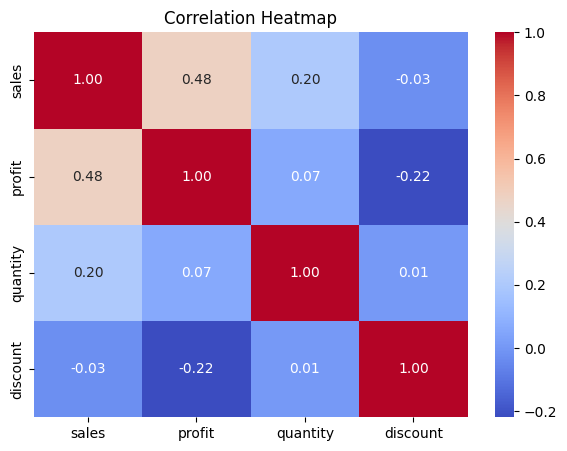

BUSINESS INSIGHTS
1. Highest Sales Category : Technology
2. Highest Profit Category: Technology
3. Lowest Profit Category : Furniture
4. Highest Sales Region   : West
RECOMMENDATIONS
• Focus on high-performing categories and regions.
• Review discounts for low-profit products.
• Monitor monthly sales trends.
• Improve pricing and profit margins.
• Use data visualization for better business decisions.
CONCLUSION
The analysis shows that data visualization helps identify sales trends, profitable categories, regional performance and areas requiring improvement. These insights can support better business decision-making.


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from google.colab import files

# UPLOAD FILE
uploaded = files.upload()

filename = next(iter(uploaded))
print("File uploaded:", filename)

# READ CSV
df = pd.read_csv(filename, encoding='latin1')

print("\nDataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# CLEAN COLUMN NAMES
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nColumns:")
print(df.columns.tolist())

# BASIC CLEANING
df = df.drop_duplicates()

# Convert important columns to numeric
for col in ['sales', 'profit', 'quantity', 'discount']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Convert date
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(
        df['order_date'], errors='coerce'
    )

print("\nCleaned Dataset:")
display(df.head())

# 5. KPI ANALYSIS

total_sales = df['sales'].sum()
total_profit = df['profit'].sum()
total_quantity = df['quantity'].sum()

profit_margin = (total_profit / total_sales) * 100
print("KEY PERFORMANCE INDICATORS")

print("Total Sales     :", round(total_sales, 2))
print("Total Profit    :", round(total_profit, 2))
print("Total Quantity  :", total_quantity)
print("Profit Margin   :", round(profit_margin, 2), "%")
# 6. CATEGORY ANALYSIS

category = df.groupby('category')[['sales', 'profit']].sum()

print("\n" + "="*50)
print("CATEGORY PERFORMANCE")
print("="*50)

display(category)

category.plot(
    kind='bar',
    figsize=(9,5),
    color=['skyblue','orange']
)

plt.title("Sales and Profit by Category")
plt.xlabel("Category")
plt.ylabel("Amount")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
# 7. REGIONAL ANALYSIS

region = df.groupby('region')[['sales', 'profit']].sum()

print("\n" + "="*50)
print("REGIONAL PERFORMANCE")
print("="*50)

display(region)

fig = px.bar(
    region.reset_index(),
    x='region',
    y='sales',
    color='profit',
    title='Sales by Region'
)

fig.show()
# 8. MONTHLY SALES TREND

if 'order_date' in df.columns:

    monthly = (
        df.set_index('order_date')
        .resample('M')['sales']
        .sum()
        .reset_index()
    )

    fig = px.line(
        monthly,
        x='order_date',
        y='sales',
        markers=True,
        title='Monthly Sales Trend'
    )

    fig.show()

# 9. DISCOUNT VS PROFIT

fig = px.scatter(
    df,
    x='discount',
    y='profit',
    color='category',
    title='Discount vs Profit'
)

fig.show()
# 10. CORRELATION HEATMAP

numeric_data = df[
    ['sales', 'profit', 'quantity', 'discount']
].corr()

plt.figure(figsize=(7,5))

sns.heatmap(
    numeric_data,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Heatmap")
plt.show()
# 11. BUSINESS INSIGHTS

highest_sales_category = category['sales'].idxmax()
highest_profit_category = category['profit'].idxmax()
lowest_profit_category = category['profit'].idxmin()
highest_sales_region = region['sales'].idxmax()
print("BUSINESS INSIGHTS")

print("1. Highest Sales Category :", highest_sales_category)
print("2. Highest Profit Category:", highest_profit_category)
print("3. Lowest Profit Category :", lowest_profit_category)
print("4. Highest Sales Region   :", highest_sales_region)

print("RECOMMENDATIONS")

print("• Focus on high-performing categories and regions.")
print("• Review discounts for low-profit products.")
print("• Monitor monthly sales trends.")
print("• Improve pricing and profit margins.")
print("• Use data visualization for better business decisions.")

print("CONCLUSION")

print(
    "The analysis shows that data visualization helps identify "
    "sales trends, profitable categories, regional performance "
    "and areas requiring improvement. These insights can support "
    "better business decision-making."
)
